## What is numerical continuation?

$$ \dot x = F(x,p),\hspace{0.5cm} x\in \mathbb{R}^n, p\in\mathbb{R}^p $$

We want to solve $F(x,p)=0$ for many choices of $p$ (typically varying a single entry of $p$). How do we do this?

## Newton's method

Pick $x_0$

$$x_{i+1} = x_i + J_i^{-1}F(x_i,p), \hspace{0.5cm} J_i = DF(x_i,p)$$

Let this converge, then take a small step in the parameter: $ds$.

Problem: requires good initial guess $x_0$, often fails despite the problem being well-posed via implicit function theorem! Requires more sophistication (cool connection to homotopy theory!), but the details are unimportant for our current purposes.

## Bifurcation detection

Search for singular points of $F(x,p)$. This boils down to checking a condition each time you take a step in the parameter, $ds$. If the condition is met a bifurcation is detected, and other methods can be used to determine its position with better accuracy.

Once a bifurcation point is detected, methods exist to find its branches.

## What is Julia?

- dynamically typed programming language, like python and matlab
- fast (10-100 times faster than python)
- uses a just-in-time compiler $\implies$ use jupyter notebooks (in vscode) for speed if you are a "hack-y" coder like me so you don't have to recompile constantly

https://cheatsheet.juliadocs.org/ is a great reference for syntax and basic things you might already know how to do in python/matlab, like working with dataframes, matrix operations, etc.

### Load the environment then packages

I reccomend setting up a dedicated environment for BifurcationKit. See https://pkgdocs.julialang.org/v1/environments/ for how to do this.

In [1]:
# using is like "import" in python. Pkg is the default package manager in julia
using Pkg 

# now we activate the package we are going to use - this will be different for you
#Pkg.activate("C:/Users/av589/Desktop/Julia/ants") # for my old windows laptop
Pkg.activate("/Users/alia/Desktop/envs/ants") # for my new macbook

# import BifurcationKit and other useful packages
using BifurcationKit
using Plots
using LaTeXStrings
using CSV
using DataFrames

  Activating project at `~/Desktop/envs/ants`


### Defining the vector field (NOD example)

In [2]:
function NOD(x,p)
    (u,b) = p

    x1 = x[1] #unpack if higher dimension


    # the ODE
    xdot = -x1 + tanh(u*x1) + b 
    [
        xdot # this is what gets returned
    ]
end

NOD (generic function with 1 method)

## Choose parameters and initial condition

In [3]:
par = (u = -0.2, b = 0.0)
u0 = [0.1]

1-element Vector{Float64}:
 0.1

### Define the problem

like object oriented programming (but secretley not, julia is techinically not object-oriented)

In [4]:
NOD_bif_prob = BifurcationProblem(
    NOD, # vector field function NOD
    u0, # initial condition
    par, # parameters
    (@optic _.u), # (@optic _.u) means the parameter we are continuing w.r.t. is u
    record_from_solution = (x, p; k...) -> (X = x[1])) # record_from_solution determines what will be saved when continuation is ran

┌─ Bifurcation problem with uType Vector{Float64}
├─ Inplace: false
├─ Dimension: 1
├─ Symmetric: false
└─ Parameter: u

## Continuation options and run continuation

In [5]:
opts_br = ContinuationPar(
    # options for continuation
    p_min = -0.3, p_max = 2.5, # parameter range to investiage
    ds = 5e-4, # typical ds value
    dsmax = 5e-3,
    dsmin = 1e-4,
    detect_bifurcation = 3,
    n_inversion = 6
)


no_bias_diagram = bifurcationdiagram(
    NOD_bif_prob, # the problem we want to solve
    PALC(), # the algorithm we are using to solve it (in this case pseudo-arclength continuation, which is a good choice to start with in general)
    2, # level of recursion to explore branches
    opts_br, # give options
    bothside = true, # compute both directions of branches
    tol_stability = 1e-8
)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 2
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 408
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at -0.3, ends at 2.5
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at u ≈ -0.30000000,                                                                     step =   0
- #  2,       bp at u ≈ +1.00000302 ∈ (+0.99999612, +1.00000302), |δp|=7e-06, [converged], δ = ( 1,  0), step = 194
- #  3, endpoint at u ≈ +2.50000000,                                                                     step = 407


### Plot results

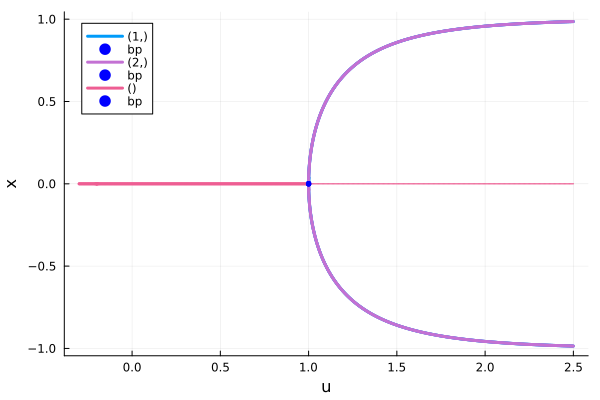

In [6]:
plot(no_bias_diagram,linewidthstable = 3,linewidthunstable = 1) # stable branches plotted thicker

There are numerical issues, we are picking out extra bifurcation points near the true bifurcation point. We can try to remedy this by passing an analytical jacobian to the continuation:

In [7]:
function J(x,p)
    # analytical jacobian
    (u,b) = p
    x1 = x[1]
    return [-1 + u*sech(u*x1)^2;;]   # Extra semicolons to ensure we return a matrix
end

NOD_bif_prob_analytic = BifurcationProblem(
    NOD, u0, par, 
    J = J, # NEW: Pass analytical jacobian to the problem
    (@optic _.u),record_from_solution = (x, p; k...) -> (X = x[1])) 


no_bias_diagram_analytic = bifurcationdiagram(NOD_bif_prob_analytic, 
    PALC(), 
    2, opts_br, bothside = true,tol_stability = 1e-8)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 2
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 408
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at -0.3, ends at 2.5
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at u ≈ -0.30000000,                                                                     step =   0
- #  2,       bp at u ≈ +1.00000302 ∈ (+0.99999612, +1.00000302), |δp|=7e-06, [converged], δ = ( 1,  0), step = 194
- #  3, endpoint at u ≈ +2.50000000,                                                                     step = 407


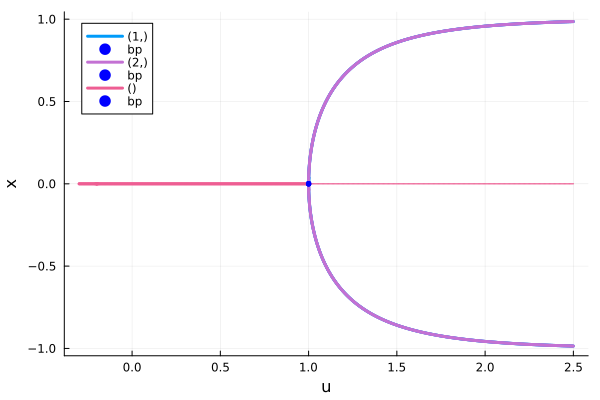

In [11]:
plot(no_bias_diagram_analytic,linewidthstable = 3,linewidthunstable = 1)

Unfourtunatley this is not sufficient. Why? The pitchfork bifurcation is highly symmetric and thus tends to not play nicely with pseudo-arclength continuation. Thankfully, since the level of symmetry is so great, you are unlikely to run into a pitchfork bifurcation in a real system, instead you will see one of its so-called unfoldings, one of which we will now investigate by increasing the bias term from zero to 0.1.

### Adding in bias term

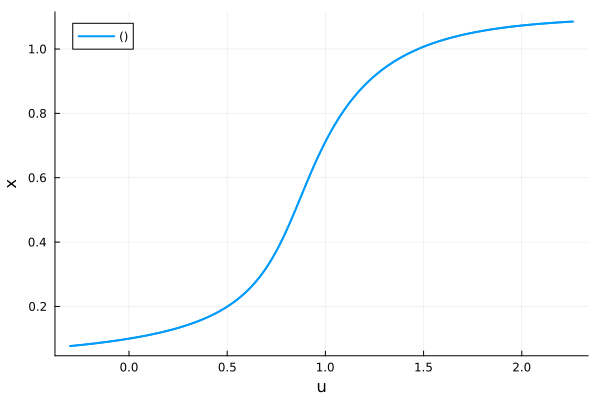

In [12]:
par = (u = -0.2, b = 0.1) # Now b is nonzero
u0 = [0.1]


NOD_bif_prob_with_bias = BifurcationProblem(NOD,u0,par, (@optic _.u), record_from_solution = (x, p; k...) -> (X = x[1])) 

opts_br = ContinuationPar(
    p_min = -0.3, p_max = 2.5,
    ds = 5e-4,
    dsmax = 5e-3,
    dsmin = 1e-4,
    detect_bifurcation = 3,
    n_inversion = 6
)

yes_bias_diagram = bifurcationdiagram(NOD_bif_prob_with_bias,PALC(),2, opts_br,bothside = true,tol_stability = 1e-8)

plot(yes_bias_diagram)

### Have to change hyperparams to find saddle-node

changed initial condition u0, and continuation range p_min, p_max so that our initial condition will "fall" onto the saddle-node.

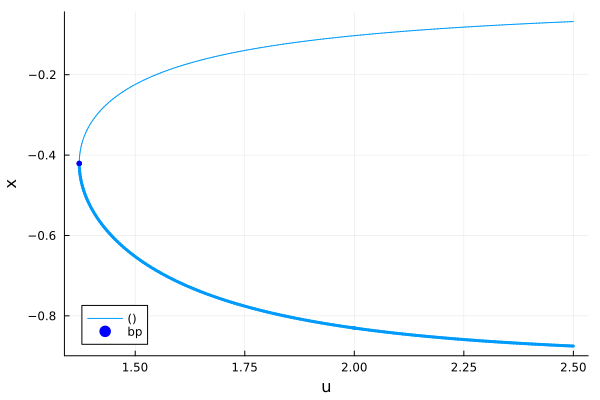

In [13]:
par = (u = 2.0, b = 0.1)
u0 = [-3.0]

NOD_bif_prob_with_bias = BifurcationProblem(NOD,u0,par, (@optic _.u), record_from_solution = (x, p; k...) -> (X = x[1])) 

opts_br = ContinuationPar(
    # options for continuation
    p_min = 1.0, p_max = 2.5,
    ds = 5e-4, # typical ds value
    dsmax = 5e-3,
    dsmin = 1e-4,
    detect_bifurcation = 3,
    n_inversion = 6
)

yes_bias_diagram2 = bifurcationdiagram(NOD_bif_prob_with_bias,PALC(),2, opts_br,bothside = true,tol_stability = 1e-8)

plot(yes_bias_diagram2,linewidthstable = 3,linewidthunstable = 1)

### Plot together

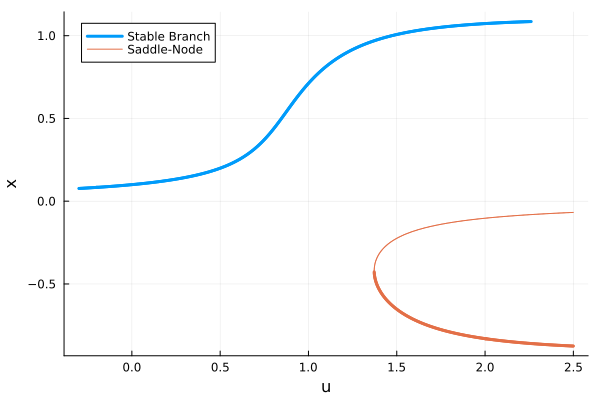

In [14]:
p1 = plot(yes_bias_diagram,ylabel = L"x",xlabel = L"u", label = "Stable Branch",linewidthstable = 3,linewidthunstable = 1)
plot!(yes_bias_diagram2,label = "Saddle-Node",plotspecialpoints=false,linewidthstable = 3,linewidthunstable = 1) # weird plotting error if you don't set this to false... not sure how to fix, best to do publication quality plotting in python anyway

### What about periodic orbits?

`bifurcationdiagram` doesen't cut it. Example from [CDC 2025 paper](https://ieeexplore.ieee.org/document/11312995):

In [15]:
# define vec field
function AntODEs(x,p)
    (mu,N,M,alpha,beta,nu,tau,k,p0,gamma0,n) = p
    R,S,p,gamma = x
    RS = R*S
    Rdot = alpha*(1-R) - beta * (M / N) * RS
    Sdot = gamma*(1-S) - beta * (N/M)*RS
    pdot =-mu*p + nu*(gamma*M*(1-S) + beta*N*RS)
    gammadot = tau^(-1)*(-gamma + gamma0 + k/(1 + (p0/p)^n))
    [
        Rdot
        Sdot
        pdot
        gammadot
    ]
end

# parameters, ic
par = (mu=0.6,N=1,M=1,alpha=0.1,beta=0.9,nu=0.45,tau=1,k=1,p0=0.2,gamma0=0.05,n=4)
u0 = [0.7,0.9,0.5,0.1]

4-element Vector{Float64}:
 0.7
 0.9
 0.5
 0.1

In [16]:
# define problem and what gets recorded
alpha_bif_problem = BifurcationProblem(AntODEs, u0,par,(@optic _.alpha),record_from_solution = (x, p; k...) -> (R = x[1], S = x[2], p = x[3],gamma = x[4]))

# take a first pass at continuation in alpha using pseudo arclength continuation
# this is like bifurcationdiagram without recursion
alpha_br_eq = continuation(alpha_bif_problem, PALC(), ContinuationPar(p_min = 0.01,p_max = 0.20,dsmax = 0.001,ds=0.0001,dsmin = 0.00001), bothside = true)

 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 559
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter alpha starts at 0.01, ends at 0.2
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at alpha ≈ +0.01000000,                                                                     step =   0
- #  2,     hopf at alpha ≈ +0.08512817 ∈ (+0.08512817, +0.08513673), |δp|=9e-06, [converged], δ = ( 2,  2), step = 268
- #  3,     hopf at alpha ≈ +0.10471780 ∈ (+0.10471716, +0.10471780), |δp|=6e-07, [converged], δ = (-2, -2), step = 346
- #  4, endpoint at alpha ≈ +0.20000000,                                                                     step = 558


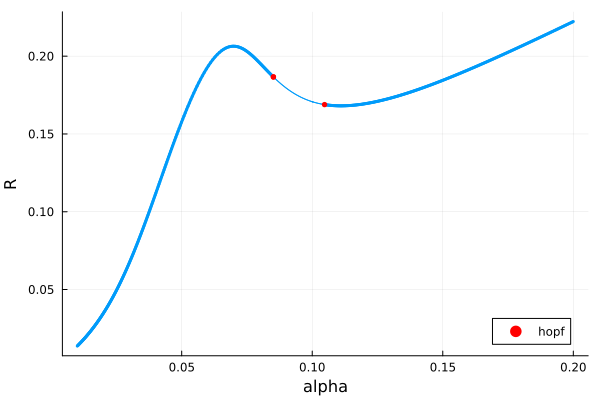

In [17]:
plot(alpha_br_eq,vars = (:param,:R),linewidthstable = 3,linewidthunstable = 1)

### Now we find the size of the oscillation:

In [18]:
opts_osc = ContinuationPar(p_min = 0.05,p_max = 0.12,dsmax = 0.001,ds=0.0001,dsmin = 0.00001)

# Now that we have the bifurcation points, use a collocation method to find the size of the oscillation

alpha_po_br2 = continuation(alpha_br_eq, 2, opts_osc,
        PeriodicOrbitOCollProblem(40, 5), # this is no longer PALC(). (40,5) affects accuracy, might have to play with it a bit
        record_from_solution = (x, p; k...) -> (R = x[1], S = x[2], p = x[3],gamma = x[4]),
        bothside=true)

 ┌─ Curve type: PeriodicOrbitCont from Hopf bifurcation point.
 ├─ Number of points: 802
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter alpha starts at 0.10465130271326321, ends at 0.1045641199674054
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at alpha ≈ +0.10467511,                                                                     step =  -1
- #  2, endpoint at alpha ≈ +0.10452587,                                                                     step = 802


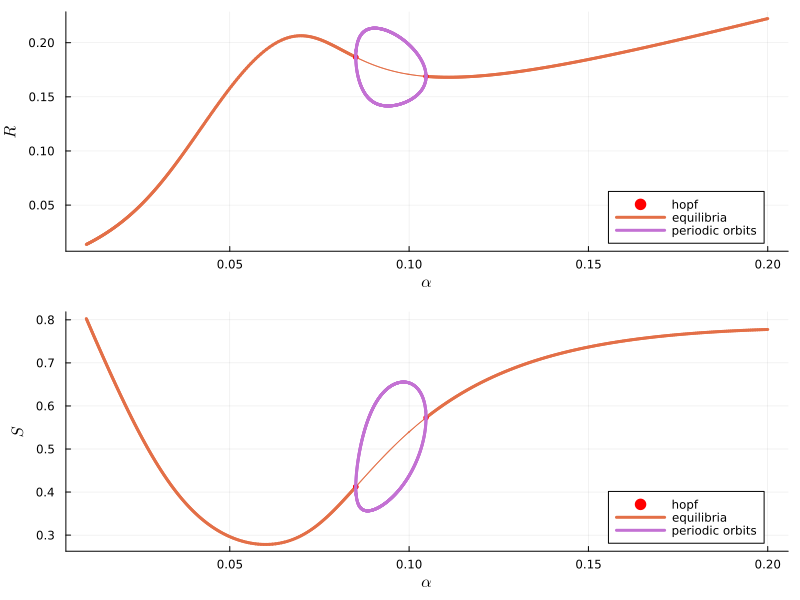

In [19]:
# plot the results (rough plot using defaults from BifurcationKit and Plots)
plot(plot(alpha_br_eq, alpha_po_br2, branchlabel = ["equilibria", "periodic orbits"],vars = (:param,:R),xlabel = L"$\alpha$",ylabel = L"$R$",linewidthstable = 3,linewidthunstable = 1),
     plot(alpha_br_eq, alpha_po_br2, branchlabel = ["equilibria", "periodic orbits"],vars = (:param,:S),xlabel = L"$\alpha$",ylabel = L"S",linewidthstable = 3,linewidthunstable = 1),layout = (2,1),size = (800,600))

### Record data to plot in python

In [17]:
alpha_eq_df = DataFrame(alpha=alpha_br_eq.param,R = alpha_br_eq.R,S = alpha_br_eq.S,stability=alpha_br_eq.stable)
alpha_po_df = DataFrame(alpha=alpha_po_br2.param,R = alpha_po_br2.R,S = alpha_po_br2.S,stability=alpha_po_br2.stable)

CSV.write("alpha_eq_df_tutorial",alpha_eq_df)
CSV.write("alpha_po_df_tutorial",alpha_po_df)


"alpha_po_df_tutorial"

Here is some example python code that uses this data to create a high-quality plot, similar to the one in the paper.

```python
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

alpha_eq_df = pd.read_csv("alpha_eq_df_tutorial")
alpha_po_df = pd.read_csv("alpha_po_df_tutorial")

# colors (from Plots.jl since I think they look better that matplotlib's default) (I know this is a crazy thing to do instead of just picking my own colors)
# For future reference, better to use colors from https://tsitsul.in/blog/coloropt/

Jbu= (0.0, 0.6056031704619725, 0.9786801190138923)
Jor = (0.8888735440600661, 0.435649148506399, 0.2781230452972766)
Jgn = (0.24222393333911896, 0.6432750821113586, 0.304448664188385)
Jpu = (0.7644400000572205, 0.4441118538379669, 0.8242975473403931)

lfs = 13 # legend font size
trans = 0.25 # alpha for fill
plt.rcParams.update({'font.size': 16})

fig,ax = plt.subplots(2,1,figsize = (8,6),dpi=600)

maskA = alpha_eq_df["stability"]
LeftA= np.where(maskA == False)[0][0]
RightA = np.where(maskA == False)[0][-1]

ax[0].plot(alpha_eq_df["alpha"][0:LeftA],alpha_eq_df["R"][0:LeftA],c = Jbu ,label = "Stable Equilibirum")
ax[0].plot(alpha_eq_df["alpha"][RightA:],alpha_eq_df["R"][RightA:],c = Jbu)
ax[0].plot(alpha_eq_df["alpha"][LeftA:RightA],alpha_eq_df["R"][LeftA:RightA],"--",c = Jbu, label = "Unstable Equilibrium",zorder=1)
ax[0].plot(alpha_po_df["alpha"],alpha_po_df["R"],zorder = 1,c = Jpu)
ax[0].scatter([alpha_eq_df["alpha"][LeftA],alpha_eq_df["alpha"][RightA]],[alpha_eq_df["R"][LeftA],alpha_eq_df["R"][RightA]],zorder = 3, color = Jor, label = "Hopf Bifurcation")
ax[0].fill(alpha_po_df["alpha"],alpha_po_df["R"],alpha = trans,color = Jpu,zorder = 0, label = "Oscillatory Region")
ax[0].set_ylabel(r"$R$")
ax[0].grid()
ax[0].set_xticklabels([])
ax[0].legend(fontsize =lfs,loc = 4)

ax[1].plot(alpha_eq_df["alpha"][0:LeftA],alpha_eq_df["S"][0:LeftA],c = Jbu ,label = "Stable Equilibrium")
ax[1].plot(alpha_eq_df["alpha"][RightA:],alpha_eq_df["S"][RightA:],c = Jbu)
ax[1].plot(alpha_eq_df["alpha"][LeftA:RightA],alpha_eq_df["S"][LeftA:RightA],"--",c = Jbu, label = "Unstable Equilibium",zorder=1)
ax[1].plot(alpha_po_df["alpha"],alpha_po_df["S"],zorder = 1,c = Jpu)
ax[1].scatter([alpha_eq_df["alpha"][LeftA],alpha_eq_df["alpha"][RightA]],[alpha_eq_df["S"][LeftA],alpha_eq_df["S"][RightA]],zorder = 3, color = Jor, label = "Hopf Bifurcation")
ax[1].fill(alpha_po_df["alpha"],alpha_po_df["S"],alpha = trans,color = Jpu,zorder = 0, label = "Oscillatory Region")
ax[1].set_xlabel(r"$\alpha$")
ax[1].set_ylabel(r"$S$")
ax[1].grid()

plt.tight_layout()
plt.show()
```